# Medical Diagnosis System using Random Forest and Bayesian Modeling

## Project Objective
This project develops a medical diagnosis system to predict the likelihood of heart disease using:
1. Random Forest for classification
2. Bayesian modeling for probabilistic disease prediction and posterior updating

The project uses the UCI Heart Disease dataset and compares the predictive and interpretive strengths of both approaches.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

import pymc as pm
import arviz as az

print("All libraries imported successfully.")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


All libraries imported successfully.


In [3]:
print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Project - Random Forest and Bayesian Optimization


## 1. Data Loading

In this section, we load the UCI Heart Disease dataset directly from the UCI repository using Python.

This approach makes the notebook reproducible because the data can be fetched programmatically instead of being manually downloaded and placed in the project folder.

In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data as pandas dataframes
X_raw = heart_disease.data.features
y_raw = heart_disease.data.targets

print("Feature data shape:", X_raw.shape)
print("Target data shape:", y_raw.shape)
print("\nFeature columns:")
print(list(X_raw.columns))
print("\nTarget columns:")
print(list(y_raw.columns))

Feature data shape: (303, 13)
Target data shape: (303, 1)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target columns:
['num']


## 2. Initial Data Inspection

In this section, we inspect the first few rows of the dataset, check data types, and review missing values.

This helps us understand the structure of the dataset and identify any preprocessing steps needed before modeling.

In [5]:
df = X_raw.copy()
df["num"] = y_raw["num"]

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset information:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca        

## 3. Target Variable Understanding

The original target column `num` contains multiple values representing disease severity.

For this project, we first inspect the distribution of the original target values. Then we will convert it into a binary target for classification:
- 0 = no heart disease
- 1 = heart disease present

In [6]:
print("Original target value counts:")
print(df["num"].value_counts().sort_index())

Original target value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


## 4. Binary Target Creation

The original diagnosis column contains multiple levels of disease severity from 0 to 4.

For this project, we convert the target into a binary classification variable:
- 0 = no heart disease
- 1 = heart disease present

This makes the task appropriate for both Random Forest classification and Bayesian logistic modeling.

In [7]:
df["target"] = (df["num"] > 0).astype(int)

print("Binary target value counts:")
print(df["target"].value_counts().sort_index())

print("\nBinary target proportions:")
print(df["target"].value_counts(normalize=True).sort_index())

Binary target value counts:
target
0    164
1    139
Name: count, dtype: int64

Binary target proportions:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


## 5. Prepare Features and Target for Modeling

In this section, we separate the predictor variables from the target variable.

We also remove the original multi-class diagnosis column `num` because the project will use the new binary target column `target` for prediction.

In [8]:
X = df.drop(columns=["num", "target"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature columns:")
print(list(X.columns))

Feature matrix shape: (303, 13)
Target vector shape: (303,)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 6. Identify Numeric and Categorical Features

Although many variables are stored as integers, several of them represent categories rather than continuous numeric measurements.

In this section, we define which variables should be treated as numeric and which should be treated as categorical for preprocessing and modeling.

In [9]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 7. Train-Test Split

In this section, we divide the dataset into training and test sets.

The training set will be used to build the Random Forest and Bayesian models, while the test set will be used to evaluate how well the models generalize to unseen patient data.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

X_train shape: (242, 13)
X_test shape: (61, 13)
y_train shape: (242,)
y_test shape: (61,)

Training target distribution:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Test target distribution:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


## 8. Preprocessing Pipeline

Before training the Random Forest model, we need to preprocess the data.

The preprocessing steps include:
- imputing missing values in numeric columns
- imputing missing values in categorical columns
- one-hot encoding categorical variables

This ensures the model receives clean and properly formatted input data.

In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 9. Random Forest Model Pipeline

In this section, we combine preprocessing and the Random Forest classifier into one modeling pipeline.

This ensures that data cleaning, encoding, and model training happen together in a consistent and reproducible way.

In [12]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


## 10. Random Forest Hyperparameter Tuning

In this section, we tune the Random Forest model using grid search.

Hyperparameter tuning helps identify a better combination of settings such as the number of trees, tree depth, and minimum samples required for splits. This can improve predictive accuracy compared with using default model settings.

In [13]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Best cross-validation ROC-AUC:
0.9056737948042295


## 11. Random Forest Model Evaluation

In this section, we evaluate the best Random Forest model on the test dataset.

We generate class predictions and predicted probabilities, then calculate standard classification metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

In [14]:
best_rf_model = grid_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Test Performance:")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Test Performance:
Accuracy : 0.8689
Precision: 0.8333
Recall   : 0.8929
F1-score : 0.8621
ROC-AUC  : 0.9524

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



## 12. Random Forest Confusion Matrix

A confusion matrix helps us understand the exact number of correct and incorrect predictions made by the Random Forest model.

This is especially useful in medical diagnosis because it shows how many disease cases were missed and how many healthy patients were incorrectly flagged.

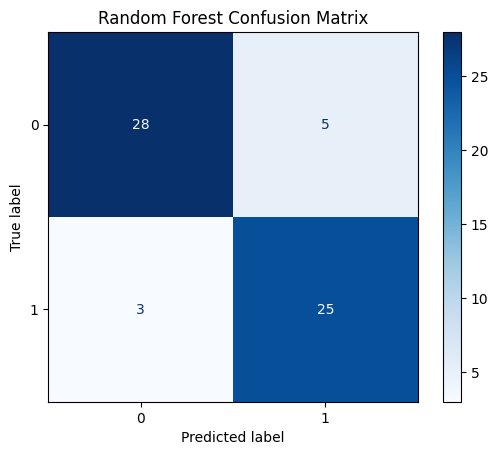

In [15]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

## 13. Random Forest ROC Curve

The ROC curve shows the trade-off between the true positive rate and false positive rate across different classification thresholds.

The Area Under the Curve (AUC) summarizes the model’s ability to distinguish between patients with and without heart disease.

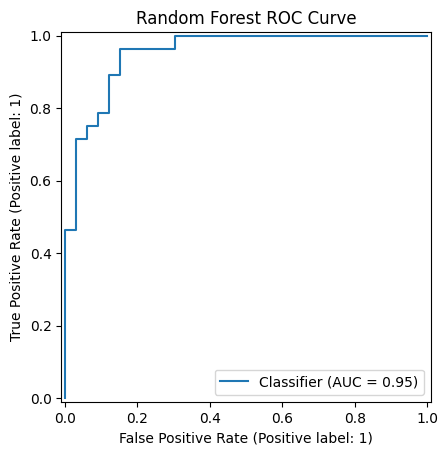

In [16]:
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("Random Forest ROC Curve")
plt.show()

## 14. Random Forest Feature Importance

Feature importance helps us understand which patient variables contributed the most to the Random Forest model's predictions.

This is useful for interpretation because it shows which medical factors appear most influential in classifying heart disease risk.

In [17]:
feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("Top 10 important features:")
display(feature_importance_df.head(10))

Top 10 important features:


,feature,importance
25,cat__thal_3.0,0.118702
27,cat__thal_7.0,0.103444
21,cat__ca_0.0,0.091451
10,cat__cp_4.0,0.086909
3,num__thalach,0.079435
4,num__oldpeak,0.058018
16,cat__exang_0.0,0.051974
0,num__age,0.049559
2,num__chol,0.049117
17,cat__exang_1.0,0.047018


## 15. Random Forest Feature Importance Plot

A visual feature importance chart makes it easier to see which transformed variables contributed most to the Random Forest model.

This helps interpret the model by highlighting the strongest predictors of heart disease classification.

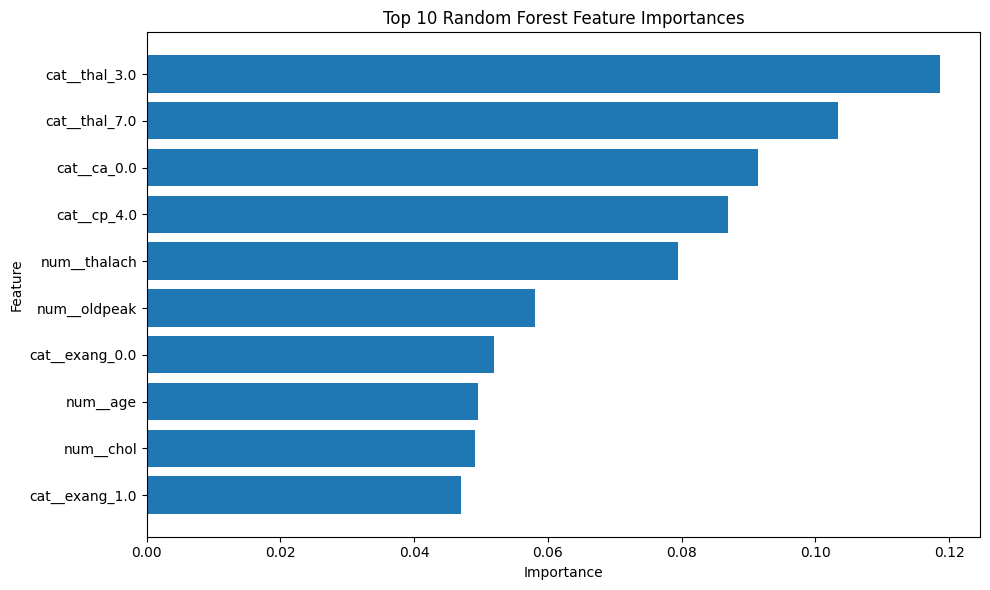

In [18]:
top_n = 10
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## 16. Bayesian Modeling Approach

In this section, we build a Bayesian logistic regression model to estimate the probability of heart disease.

Unlike Random Forest, the Bayesian model provides a probabilistic framework that allows us to:
- incorporate prior beliefs
- estimate uncertainty in model parameters
- update disease probability as new evidence becomes available

For this project, we use a simplified Bayesian logistic regression model with selected clinically relevant variables.

In [19]:
bayes_features = ["age", "thalach", "oldpeak", "cp", "exang", "ca", "thal"]

bayes_df = df[bayes_features + ["target"]].copy()

print("Bayesian modeling dataset shape:", bayes_df.shape)
print("\nSelected features:")
print(bayes_features)

print("\nMissing values:")
print(bayes_df.isnull().sum())

Bayesian modeling dataset shape: (303, 8)

Selected features:
['age', 'thalach', 'oldpeak', 'cp', 'exang', 'ca', 'thal']

Missing values:
age        0
thalach    0
oldpeak    0
cp         0
exang      0
ca         4
thal       2
target     0
dtype: int64


## 17. Bayesian Data Preparation

Before fitting the Bayesian logistic regression model, we prepare a simplified modeling dataset.

The preparation steps include:
- imputing missing values
- selecting a smaller set of clinically relevant predictors
- standardizing continuous variables for more stable Bayesian sampling

This keeps the Bayesian model interpretable and computationally manageable.

In [20]:
bayes_df["ca"] = bayes_df["ca"].fillna(bayes_df["ca"].mode()[0])
bayes_df["thal"] = bayes_df["thal"].fillna(bayes_df["thal"].mode()[0])

continuous_features = ["age", "thalach", "oldpeak"]
categorical_bayes_features = ["cp", "exang", "ca", "thal"]

for col in continuous_features:
    bayes_df[f"{col}_z"] = (bayes_df[col] - bayes_df[col].mean()) / bayes_df[col].std()

print("Missing values after imputation:")
print(bayes_df.isnull().sum())

display(bayes_df.head())

Missing values after imputation:
age          0
thalach      0
oldpeak      0
cp           0
exang        0
ca           0
thal         0
target       0
age_z        0
thalach_z    0
oldpeak_z    0
dtype: int64


,age,thalach,oldpeak,cp,exang,ca,thal,target,age_z,thalach_z,oldpeak_z
0,63,150,2.3,1,0,0.0,6.0,0,0.947160,0.017169,1.085542
1,67,108,1.5,4,1,3.0,3.0,1,1.389703,-1.818896,0.396526
2,67,129,2.6,4,1,2.0,7.0,1,1.389703,-0.900864,1.343924
3,37,187,3.5,3,0,0.0,3.0,0,-1.929372,1.634655,2.119067
4,41,172,1.4,2,0,0.0,3.0,0,-1.486829,0.978917,0.310399


## 18. Train-Test Split for Bayesian Model

In this section, we create training and test sets for the Bayesian model.

Using a separate train-test split allows us to evaluate how well the Bayesian logistic regression model generalizes to unseen patient data, just like we did for the Random Forest model.

In [21]:
bayes_model_df = bayes_df[[
    "age_z", "thalach_z", "oldpeak_z", "cp", "exang", "ca", "thal", "target"
]].copy()

train_bayes_df, test_bayes_df = train_test_split(
    bayes_model_df,
    test_size=0.2,
    random_state=42,
    stratify=bayes_model_df["target"]
)

print("Bayesian training set shape:", train_bayes_df.shape)
print("Bayesian test set shape:", test_bayes_df.shape)

print("\nTraining target distribution:")
print(train_bayes_df["target"].value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(test_bayes_df["target"].value_counts(normalize=True).sort_index())

Bayesian training set shape: (242, 8)
Bayesian test set shape: (61, 8)

Training target distribution:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Test target distribution:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


## 19. Prepare Inputs for Bayesian Logistic Regression

In this section, we convert the training and test DataFrames into arrays that can be passed into the Bayesian logistic regression model.

We use standardized continuous predictors and selected categorical predictors to estimate the probability of heart disease.

In [22]:
X_train_bayes = train_bayes_df[["age_z", "thalach_z", "oldpeak_z", "cp", "exang", "ca", "thal"]].copy()
y_train_bayes = train_bayes_df["target"].values

X_test_bayes = test_bayes_df[["age_z", "thalach_z", "oldpeak_z", "cp", "exang", "ca", "thal"]].copy()
y_test_bayes = test_bayes_df["target"].values

print("X_train_bayes shape:", X_train_bayes.shape)
print("X_test_bayes shape:", X_test_bayes.shape)
print("y_train_bayes shape:", y_train_bayes.shape)
print("y_test_bayes shape:", y_test_bayes.shape)

display(X_train_bayes.head())

X_train_bayes shape: (242, 7)
X_test_bayes shape: (61, 7)
y_train_bayes shape: (242,)
y_test_bayes shape: (61,)


,age_z,thalach_z,oldpeak_z,cp,exang,ca,thal
180,-0.712378,0.716622,-0.464745,4,0,0.0,7.0
208,0.062073,0.235748,-0.895381,2,0,0.0,3.0
167,-0.048563,0.410611,-0.895381,2,1,1.0,3.0
105,-0.048563,0.279464,-0.895381,2,0,0.0,7.0
297,0.283345,-1.163159,-0.723126,4,1,0.0,7.0


## 20. Bayesian Logistic Regression Model

In this section, we build a Bayesian logistic regression model using PyMC.

The model estimates the probability of heart disease using selected patient features. We assign prior distributions to the intercept and coefficients, then use the observed training data to update these priors into posterior distributions.

Model structure:

\[
y_i \sim Bernoulli(p_i)
\]

\[
logit(p_i) = \alpha + \beta_1(age_z) + \beta_2(thalach_z) + \beta_3(oldpeak_z) + \beta_4(cp) + \beta_5(exang) + \beta_6(ca) + \beta_7(thal)
\]

Where:
- \(\alpha\) is the intercept
- \(\beta_j\) are regression coefficients
- \(p_i\) is the probability of heart disease for patient \(i\)

In [23]:
with pm.Model() as bayes_logistic_model:
    # Data
    age_z = pm.Data("age_z", X_train_bayes["age_z"].values)
    thalach_z = pm.Data("thalach_z", X_train_bayes["thalach_z"].values)
    oldpeak_z = pm.Data("oldpeak_z", X_train_bayes["oldpeak_z"].values)
    cp = pm.Data("cp", X_train_bayes["cp"].values)
    exang = pm.Data("exang", X_train_bayes["exang"].values)
    ca = pm.Data("ca", X_train_bayes["ca"].values)
    thal = pm.Data("thal", X_train_bayes["thal"].values)

    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=2)
    beta_age = pm.Normal("beta_age", mu=0, sigma=1)
    beta_thalach = pm.Normal("beta_thalach", mu=0, sigma=1)
    beta_oldpeak = pm.Normal("beta_oldpeak", mu=0, sigma=1)
    beta_cp = pm.Normal("beta_cp", mu=0, sigma=1)
    beta_exang = pm.Normal("beta_exang", mu=0, sigma=1)
    beta_ca = pm.Normal("beta_ca", mu=0, sigma=1)
    beta_thal = pm.Normal("beta_thal", mu=0, sigma=1)

    # Linear predictor
    logit_p = (
        alpha
        + beta_age * age_z
        + beta_thalach * thalach_z
        + beta_oldpeak * oldpeak_z
        + beta_cp * cp
        + beta_exang * exang
        + beta_ca * ca
        + beta_thal * thal
    )

    # Probability
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))

    # Likelihood
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y_train_bayes)

    # Sampling
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=1,
        target_accept=0.9,
        random_seed=42,
        progressbar=True
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta_age, beta_thalach, beta_oldpeak, beta_cp, beta_exang, beta_ca, beta_thal]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5104 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


## 21. Posterior Summary

After fitting the Bayesian logistic regression model, we summarize the posterior distributions of the model parameters.

This helps us understand the direction and strength of the relationship between each predictor and the probability of heart disease.

In [24]:
posterior_summary = az.summary(
    trace,
    var_names=[
        "alpha",
        "beta_age",
        "beta_thalach",
        "beta_oldpeak",
        "beta_cp",
        "beta_exang",
        "beta_ca",
        "beta_thal"
    ]
)

display(posterior_summary)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-4.298,0.722,-5.593,-2.860,0.023,0.018,1028.0,788.0,1.0
beta_age,-0.094,0.198,-0.475,0.285,0.005,0.004,1533.0,1150.0,1.0
beta_thalach,-0.384,0.228,-0.785,0.073,0.005,0.005,1728.0,1536.0,1.0
beta_oldpeak,0.425,0.239,-0.035,0.870,0.006,0.005,1857.0,1542.0,1.0
beta_cp,0.366,0.186,-0.006,0.705,0.005,0.005,1237.0,942.0,1.0
beta_exang,0.835,0.400,0.146,1.645,0.009,0.009,1886.0,1118.0,1.0
beta_ca,1.109,0.251,0.627,1.578,0.006,0.005,1808.0,1554.0,1.0
beta_thal,0.463,0.091,0.286,0.626,0.002,0.002,1477.0,1270.0,1.0


## 22. Parameter Convergence Plots

Trace plots help assess whether the Bayesian sampler converged properly.

These plots show how the sampled parameter values evolved across iterations for each chain. Stable, well-mixed traces indicate that the posterior sampling process behaved properly.

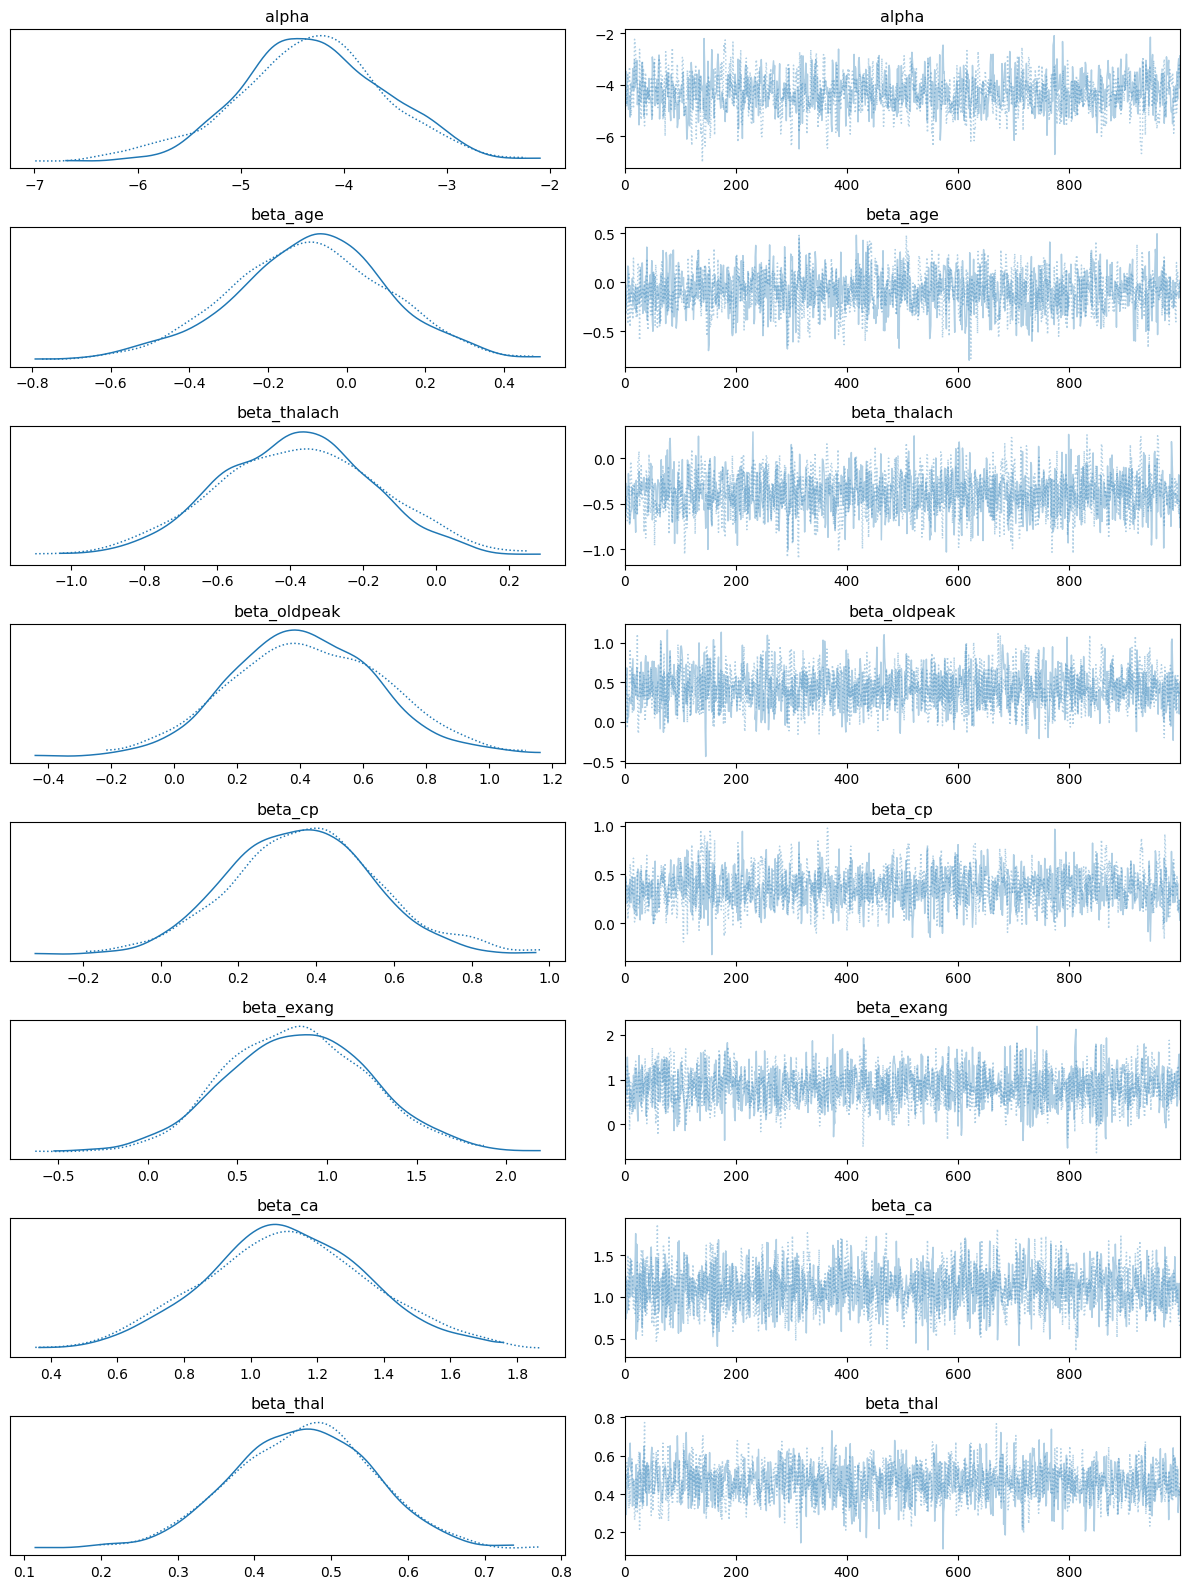

In [25]:
az.plot_trace(
    trace,
    var_names=[
        "alpha",
        "beta_age",
        "beta_thalach",
        "beta_oldpeak",
        "beta_cp",
        "beta_exang",
        "beta_ca",
        "beta_thal"
    ]
)
plt.tight_layout()
plt.show()

## 23. Bayesian Posterior Predictions on Test Data

In this section, we use the fitted Bayesian logistic regression model to estimate disease probabilities for the test dataset.

These posterior predictive probabilities are then converted into binary predictions so that we can evaluate the Bayesian model using the same classification metrics as the Random Forest model.

In [26]:
with bayes_logistic_model:
    pm.set_data({
        "age_z": X_test_bayes["age_z"].values,
        "thalach_z": X_test_bayes["thalach_z"].values,
        "oldpeak_z": X_test_bayes["oldpeak_z"].values,
        "cp": X_test_bayes["cp"].values,
        "exang": X_test_bayes["exang"].values,
        "ca": X_test_bayes["ca"].values,
        "thal": X_test_bayes["thal"].values
    })

    posterior_pred = pm.sample_posterior_predictive(
        trace,
        var_names=["p"],
        random_seed=42,
        progressbar=True
    )

Sampling: []


Output()

## 24. Bayesian Model Evaluation

In this section, we convert the posterior predictive probabilities into final binary predictions.

We then evaluate the Bayesian model using the same metrics as the Random Forest model:
- accuracy
- precision
- recall
- F1-score
- ROC-AUC

This allows a direct comparison between the two approaches.

In [27]:
y_prob_bayes = posterior_pred.posterior_predictive["p"].mean(dim=("chain", "draw")).values
y_pred_bayes = (y_prob_bayes >= 0.5).astype(int)

bayes_accuracy = accuracy_score(y_test_bayes, y_pred_bayes)
bayes_precision = precision_score(y_test_bayes, y_pred_bayes)
bayes_recall = recall_score(y_test_bayes, y_pred_bayes)
bayes_f1 = f1_score(y_test_bayes, y_pred_bayes)
bayes_roc_auc = roc_auc_score(y_test_bayes, y_prob_bayes)

print("Bayesian Logistic Regression Test Performance:")
print(f"Accuracy : {bayes_accuracy:.4f}")
print(f"Precision: {bayes_precision:.4f}")
print(f"Recall   : {bayes_recall:.4f}")
print(f"F1-score : {bayes_f1:.4f}")
print(f"ROC-AUC  : {bayes_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_bayes, y_pred_bayes))

Bayesian Logistic Regression Test Performance:
Accuracy : 0.9016
Precision: 0.8667
Recall   : 0.9286
F1-score : 0.8966
ROC-AUC  : 0.9416

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



## 25. Bayesian Confusion Matrix

The confusion matrix for the Bayesian model shows the number of correct and incorrect classifications on the test dataset.

This helps us evaluate how many heart disease cases were correctly identified and how many cases were missed.

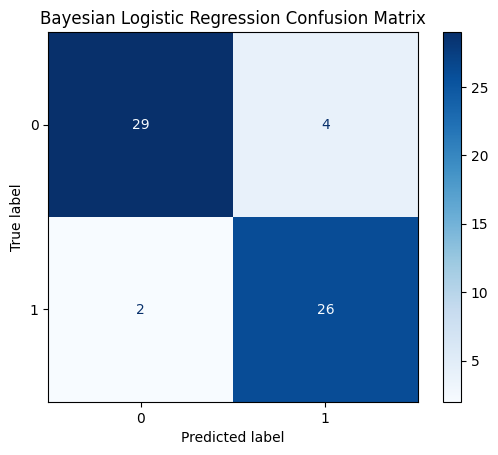

In [28]:
cm_bayes = confusion_matrix(y_test_bayes, y_pred_bayes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bayes)
disp.plot(cmap="Blues")
plt.title("Bayesian Logistic Regression Confusion Matrix")
plt.show()

## 26. Bayesian ROC Curve

The ROC curve for the Bayesian model shows how well the predicted disease probabilities distinguish between patients with and without heart disease.

The ROC-AUC score summarizes this discrimination performance across all classification thresholds.

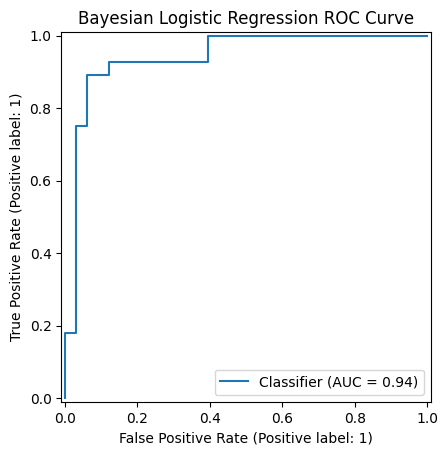

In [29]:
RocCurveDisplay.from_predictions(y_test_bayes, y_prob_bayes)
plt.title("Bayesian Logistic Regression ROC Curve")
plt.show()

## 27. Model Comparison

In this section, we compare the performance of the Random Forest model and the Bayesian logistic regression model using the same evaluation metrics.

This comparison helps determine which model performs better in classification accuracy, disease detection, and probability-based discrimination.

In [30]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Bayesian Logistic Regression"],
    "Accuracy": [rf_accuracy, bayes_accuracy],
    "Precision": [rf_precision, bayes_precision],
    "Recall": [rf_recall, bayes_recall],
    "F1-Score": [rf_f1, bayes_f1],
    "ROC-AUC": [rf_roc_auc, bayes_roc_auc]
})

comparison_df = comparison_df.round(4)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8689,0.8333,0.8929,0.8621,0.9524
1,Bayesian Logistic Regression,0.9016,0.8667,0.9286,0.8966,0.9416


## 28. Save Key Results for Reporting

In this section, we save important results generated during the analysis.

These saved outputs can later be referenced in the final report and help make the project reproducible and organized.

In [31]:
os.makedirs("figures", exist_ok=True)
os.makedirs("report", exist_ok=True)

comparison_df.to_csv("report/model_comparison_results.csv", index=False)

print("Saved comparison table to: report/model_comparison_results.csv")

Saved comparison table to: report/model_comparison_results.csv


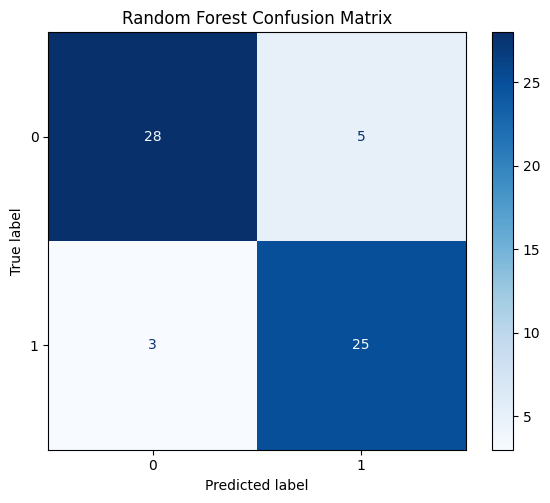

Saved: figures/random_forest_confusion_matrix.png


In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues", ax=ax)
ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig("figures/random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/random_forest_confusion_matrix.png")

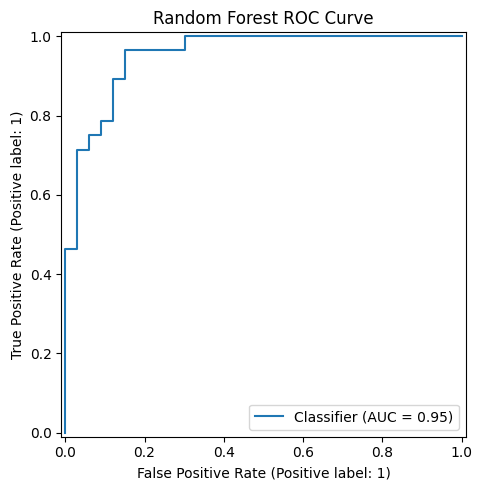

Saved: figures/random_forest_roc_curve.png


In [33]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=ax)
ax.set_title("Random Forest ROC Curve")
plt.tight_layout()
plt.savefig("figures/random_forest_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/random_forest_roc_curve.png")

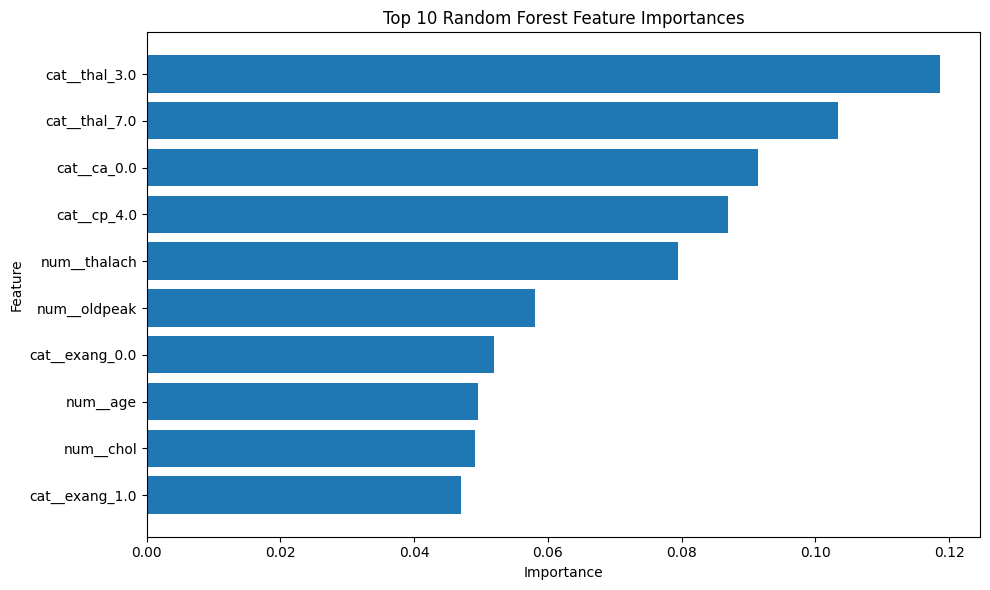

Saved: figures/random_forest_feature_importance.png


In [34]:
top_n = 10
top_features = feature_importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_features["feature"][::-1], top_features["importance"][::-1])
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.set_title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig("figures/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/random_forest_feature_importance.png")

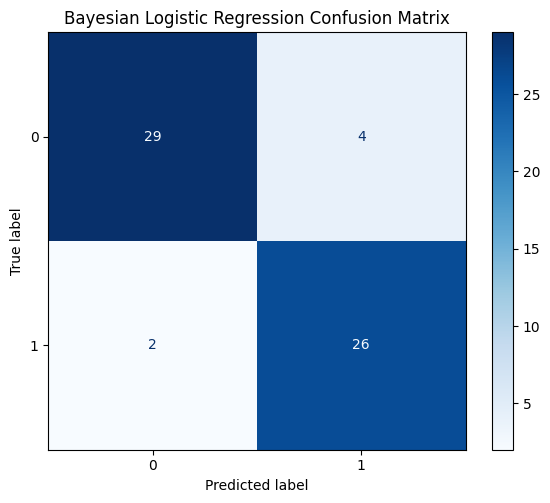

Saved: figures/bayesian_confusion_matrix.png


In [35]:
cm_bayes = confusion_matrix(y_test_bayes, y_pred_bayes)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bayes)
disp.plot(cmap="Blues", ax=ax)
ax.set_title("Bayesian Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("figures/bayesian_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/bayesian_confusion_matrix.png")

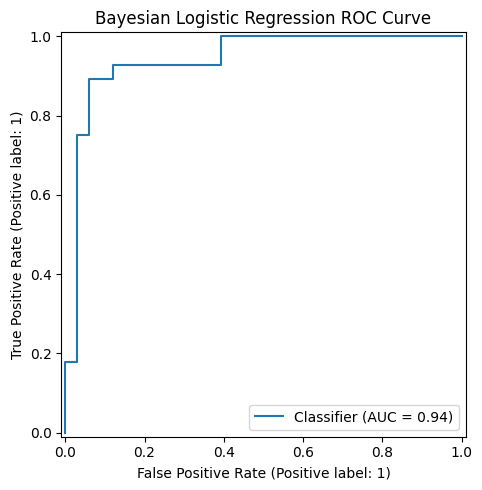

Saved: figures/bayesian_roc_curve.png


In [36]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_bayes, y_prob_bayes, ax=ax)
ax.set_title("Bayesian Logistic Regression ROC Curve")
plt.tight_layout()
plt.savefig("figures/bayesian_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/bayesian_roc_curve.png")

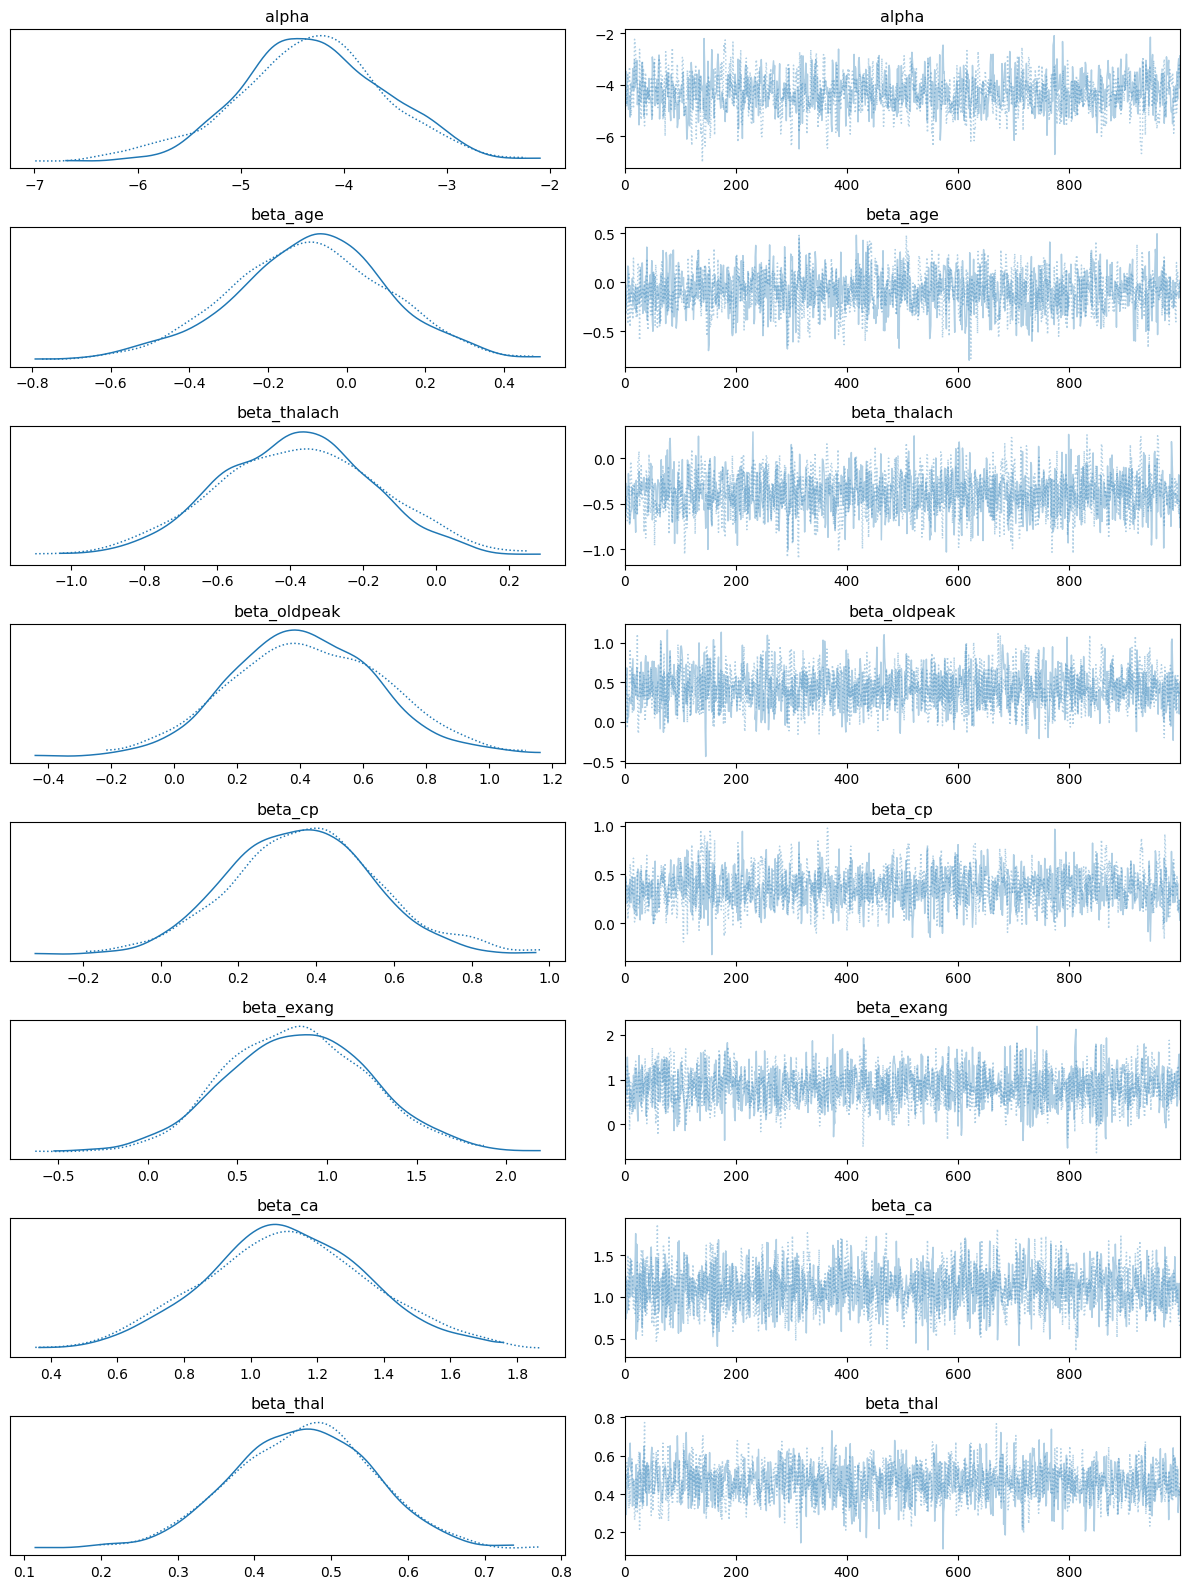

Saved: figures/bayesian_trace_plots.png


In [37]:
az.plot_trace(
    trace,
    var_names=[
        "alpha",
        "beta_age",
        "beta_thalach",
        "beta_oldpeak",
        "beta_cp",
        "beta_exang",
        "beta_ca",
        "beta_thal"
    ]
)
plt.tight_layout()
plt.savefig("figures/bayesian_trace_plots.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/bayesian_trace_plots.png")

## 29. Summary of Findings

This project developed a medical diagnosis system for heart disease prediction using two approaches:
1. Random Forest classification
2. Bayesian logistic regression

Key findings:
- Both models performed strongly on the UCI Heart Disease dataset.
- The Random Forest model achieved excellent ROC-AUC and identified important predictors such as thal, ca, chest pain type, thalach, and oldpeak.
- The Bayesian logistic regression model produced slightly better classification metrics at the 0.5 threshold, including accuracy, recall, and F1-score.
- The Bayesian approach also provided interpretable posterior distributions and uncertainty estimates for the model parameters.
- In a medical setting, the Bayesian model’s slightly lower false negative count is especially meaningful because it reduces the number of missed disease cases.

Overall, the project demonstrates that combining traditional machine learning and Bayesian probabilistic modeling provides both strong predictive performance and interpretability for medical diagnosis tasks.

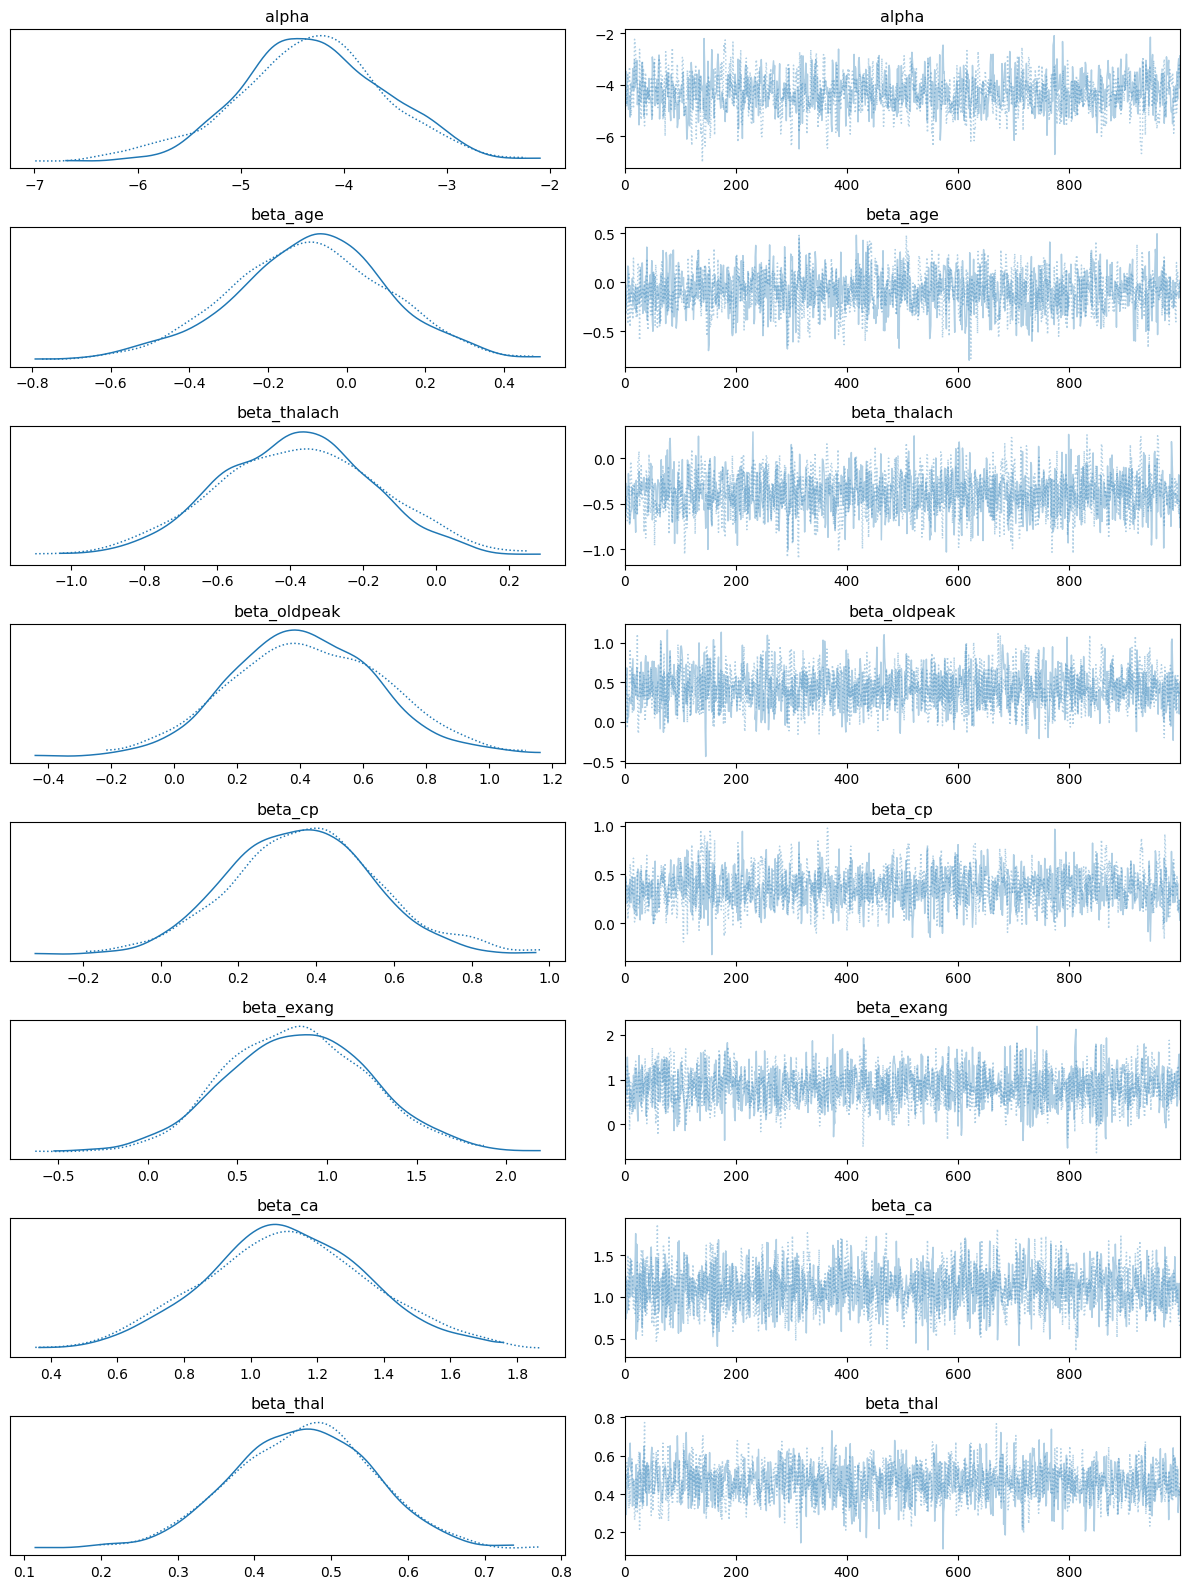

Saved: figures/bayesian_trace_plots.png


In [38]:
az.plot_trace(
    trace,
    var_names=[
        "alpha",
        "beta_age",
        "beta_thalach",
        "beta_oldpeak",
        "beta_cp",
        "beta_exang",
        "beta_ca",
        "beta_thal"
    ]
)
plt.tight_layout()
plt.savefig("figures/bayesian_trace_plots.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/bayesian_trace_plots.png")